## Homework 1: Gradient Descent

### Exercise 5: Gradient Descent on the Rosenbrock Function

In [69]:
import numpy as np
import matplotlib.pyplot as plt

In [70]:
theta0_list = [
    np.array([-1.5, 2]),
    np.array([-1, 0]),
    np.array([0, 2]),
    np.array([1.5, 1.5])
]

maxit = 20000
tolL = 0.0005
toltheta = 0.0005

etas_const = [10e-3, 10e-4, 10e-5]

In [71]:
def L(theta):
    theta = np.array(theta)
    return (1 - theta[0]) ** 2 + 100 * (theta[1] - theta[0] ** 2) ** 2

def grad_L(theta):
    theta = np.array(theta)
    g0 = -2 * (1 - theta[0]) - 400 * theta[0] * (theta[1] - theta[0]**2)
    g1 = 200 * (theta[1] - theta[0]**2)
    return np.array([g0, g1])

def backtracking(L, grad_L, theta, eta0=1.0, beta=0.5, c=1e-4):
    """
    Return a step size eta that satisfies the Armijo condition:
        L(theta - eta*g) <= L(theta) - c * eta * ||g||^2
    Inputs:
      - L:      R^n -> R
      - grad_L: R^n -> R^d
      - theta:  current point (np.ndarray)
      - eta0:   initial step size
      - beta:   shrinking factor in (0,1)
      - c:      Armijo constant in (0,1)
    """
    eta = eta0
    g = grad_L(theta)
    g_norm2 = np.dot(g, g)
    while L(theta - eta * g) > L(theta) - c * eta * g_norm2:
        eta *= beta
    return eta

def gradient_descent(theta0, eta0, maxit, tolL, toltheta, toggle=True,
                     bt_beta=0.5, bt_c=1e-4):
    theta = np.array(theta0, dtype=float).copy()
    thetas = [theta.copy()]
    losses = [L(theta)]

    for it in range(maxit):
        g = grad_L(theta)

        # stopping: small gradient norm
        if np.linalg.norm(g) < tolL:
            break

        if toggle:
            eta = backtracking(L, grad_L, theta, eta0=eta0, beta=bt_beta, c=bt_c)
        else:
            eta = eta0

        theta_next = theta - eta * g

        # stopping: small parameter change
        if np.linalg.norm(theta_next - theta) < toltheta:
            theta = theta_next
            thetas.append(theta.copy())
            losses.append(L(theta))
            break

        theta = theta_next
        thetas.append(theta.copy())
        losses.append(L(theta))

    return theta, it, thetas, losses


In [72]:
def rosenbrock_levelsets(axis, xlim=(-3, 3), ylim=(-3, 3), ngrid=400, ncontours=18):
    xs = np.linspace(xlim[0], xlim[1], ngrid)
    ys = np.linspace(ylim[0], ylim[1], ngrid)
    X, Y = np.meshgrid(xs, ys)
    Z = (1 - X) ** 2 + 100.0 * (Y - X ** 2) ** 2

    # loss values span several orders of magnitude, and log spacing allows to visualize both the narrow valley near 
    # the minimum and the steep outer regions simultaneously.
    levels = np.logspace(-1, 3, ncontours)

    cs = axis.contour(X, Y, Z, levels=levels)
    axis.clabel(cs, inline=True, fontsize=7)
    axis.axhline(0, lw=0.5, color='k')
    axis.axvline(0, lw=0.5, color='k')
    axis.set_aspect('equal', 'box')
    axis.set_xlabel(r'$\theta_1$')
    axis.set_ylabel(r'$\theta_2$')
    axis.grid(alpha=0.2)
    axis.set_xlim(xlim)
    axis.set_ylim(ylim)


def plot_one_theta0(theta0, etas_const, eta_bt=1.0, maxit=10000,
                    tolL=1e-6, toltheta=1e-10, xlim=(-3, 3), ylim=(-3, 3), ncontours=18):

    fig, axs = plt.subplots(2, len(etas_const) + 1, figsize=(22, 10))
    fig.suptitle(
        f"theta_0 = ({float(theta0[0]):.1f}, {float(theta0[1]):.1f})",
        fontsize=28
    )

    for j, eta0 in enumerate(etas_const):
        _, _, thetas, losses = gradient_descent(
            theta0=theta0,
            eta0=eta0,
            maxit=maxit,
            tolL=tolL,
            toltheta=toltheta,
            toggle=False
        )
        thetas = np.array(thetas)

        # Trajectory plot
        ax_path = axs[0, j]
        rosenbrock_levelsets(ax_path, xlim=xlim, ylim=ylim, ncontours=ncontours)
        ax_path.plot(thetas[:, 0], thetas[:, 1], linewidth=0.8)
        ax_path.scatter(thetas[:, 0], thetas[:, 1], s=12, label="successive thetas")
        ax_path.set_title(r"η" + f" = {eta0}", fontsize=16)
        ax_path.legend(loc="lower center", fontsize=8)

        # Loss plot
        ax_loss = axs[1, j]
        ax_loss.plot(losses)
        ax_loss.set_title(f"Loss (η={eta0})", fontsize=14)
        ax_loss.set_xlabel("Iteration")
        ax_loss.set_ylabel("L(theta)")
        ax_loss.grid(alpha=0.2)

    _, _, thetas, losses = gradient_descent(
        theta0=theta0,
        eta0=eta_bt,
        maxit=maxit,
        tolL=tolL,
        toltheta=toltheta,
        toggle=True
    )
    thetas = np.array(thetas)

    # Trajectory plot
    ax_path = axs[0, -1]
    rosenbrock_levelsets(ax_path, xlim=xlim, ylim=ylim, ncontours=ncontours)
    ax_path.plot(thetas[:, 0], thetas[:, 1], linewidth=0.8)
    ax_path.scatter(thetas[:, 0], thetas[:, 1], s=12, label="successive thetas")
    ax_path.set_title("backtracking", fontsize=16)
    ax_path.legend(loc="lower center", fontsize=8)

    # Loss plot
    ax_loss = axs[1, -1]
    ax_loss.plot(losses)
    ax_loss.set_title("Loss (backtracking)", fontsize=14)
    ax_loss.set_xlabel("Iteration")
    ax_loss.set_ylabel("L(theta)")
    ax_loss.grid(alpha=0.2)

    plt.tight_layout()
    plt.show()


/var/folders/r0/xh7tlw6d25s7y_rpyn703zjw0000gn/T/ipykernel_2528/1726074894.py:3: RuntimeWarning: overflow encountered in scalar power
  return (1 - theta[0]) ** 2 + 100 * (theta[1] - theta[0] ** 2) ** 2
/var/folders/r0/xh7tlw6d25s7y_rpyn703zjw0000gn/T/ipykernel_2528/1726074894.py:7: RuntimeWarning: overflow encountered in scalar power
  g0 = -2 * (1 - theta[0]) - 400 * theta[0] * (theta[1] - theta[0]**2)
/var/folders/r0/xh7tlw6d25s7y_rpyn703zjw0000gn/T/ipykernel_2528/1726074894.py:8: RuntimeWarning: overflow encountered in scalar power
  g1 = 200 * (theta[1] - theta[0]**2)
/var/folders/r0/xh7tlw6d25s7y_rpyn703zjw0000gn/T/ipykernel_2528/1726074894.py:3: RuntimeWarning: invalid value encountered in scalar subtract
  return (1 - theta[0]) ** 2 + 100 * (theta[1] - theta[0] ** 2) ** 2
/var/folders/r0/xh7tlw6d25s7y_rpyn703zjw0000gn/T/ipykernel_2528/1726074894.py:7: RuntimeWarning: invalid value encountered in scalar subtract
  g0 = -2 * (1 - theta[0]) - 400 * theta[0] * (theta[1] - theta[0]*

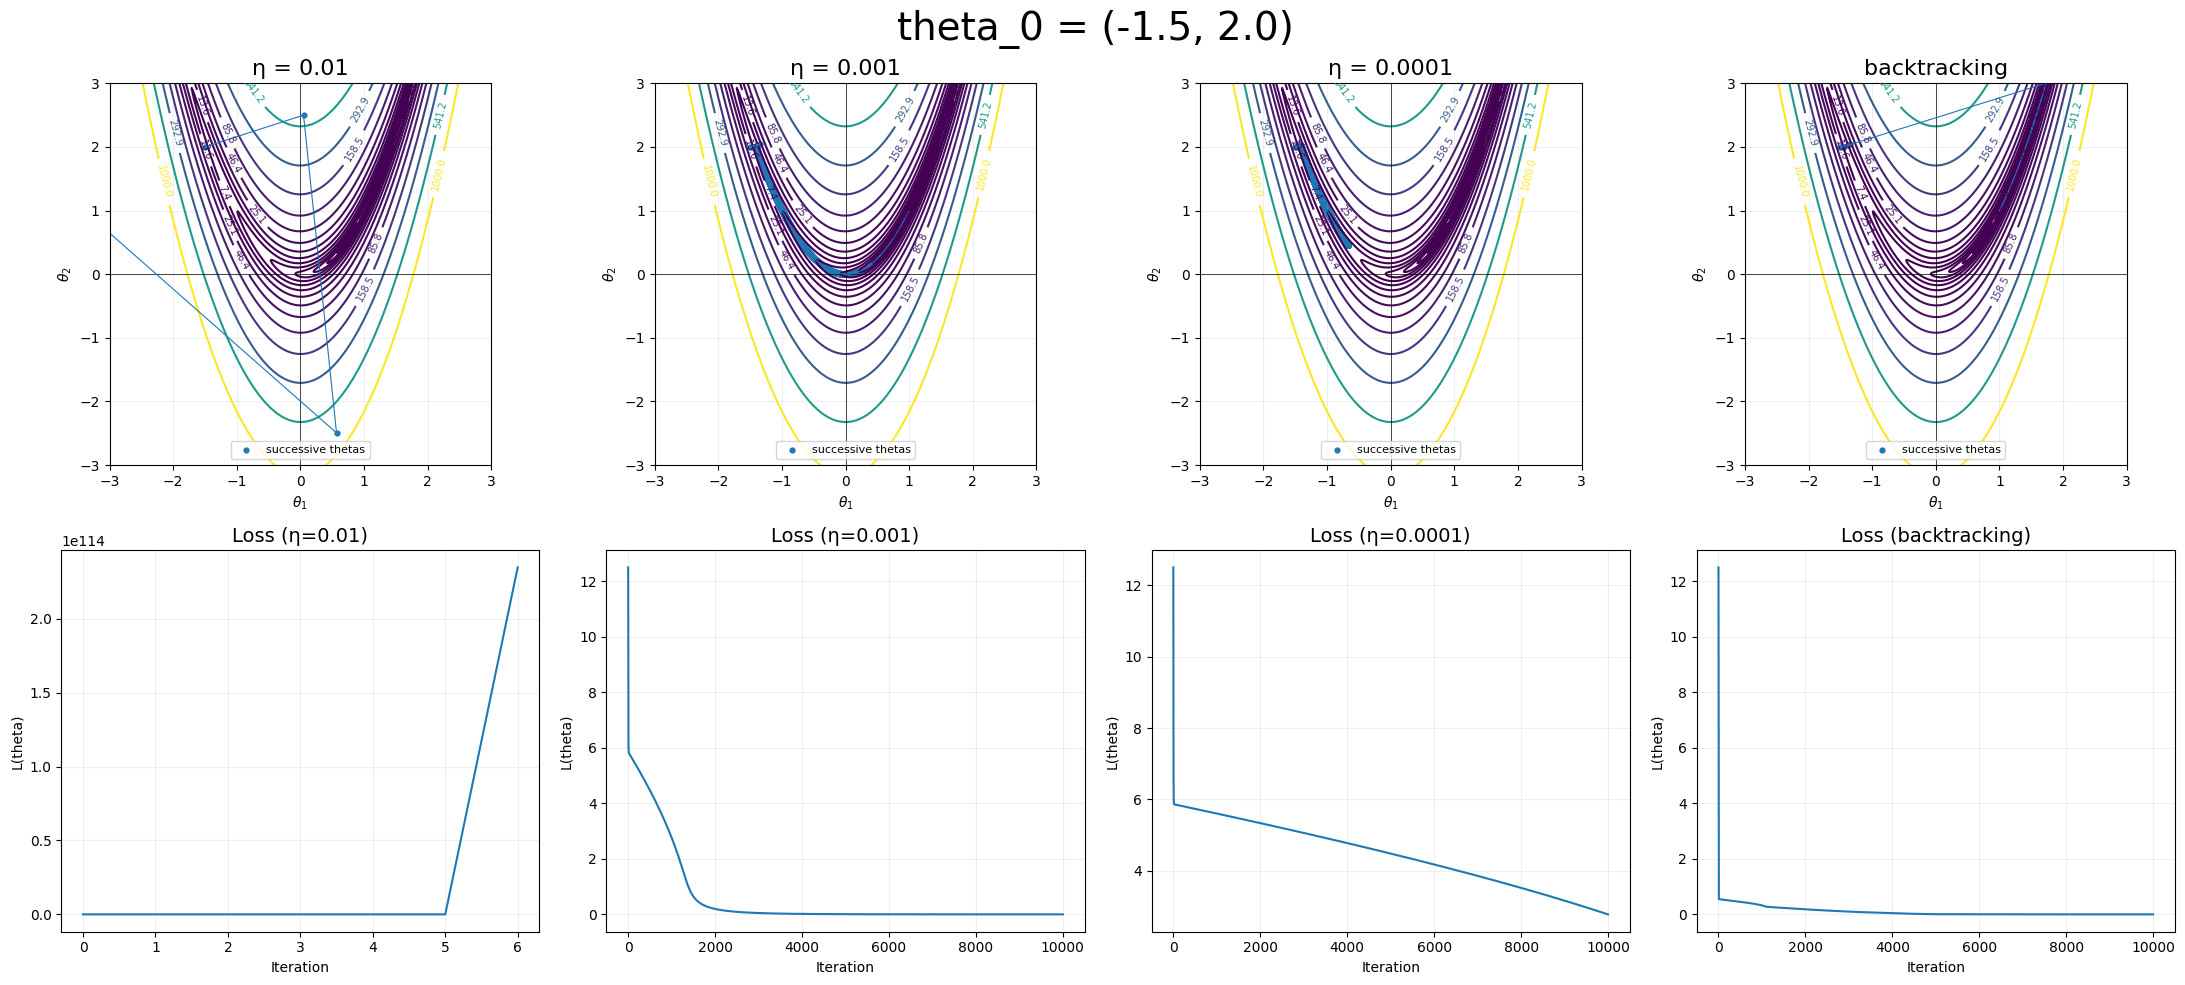

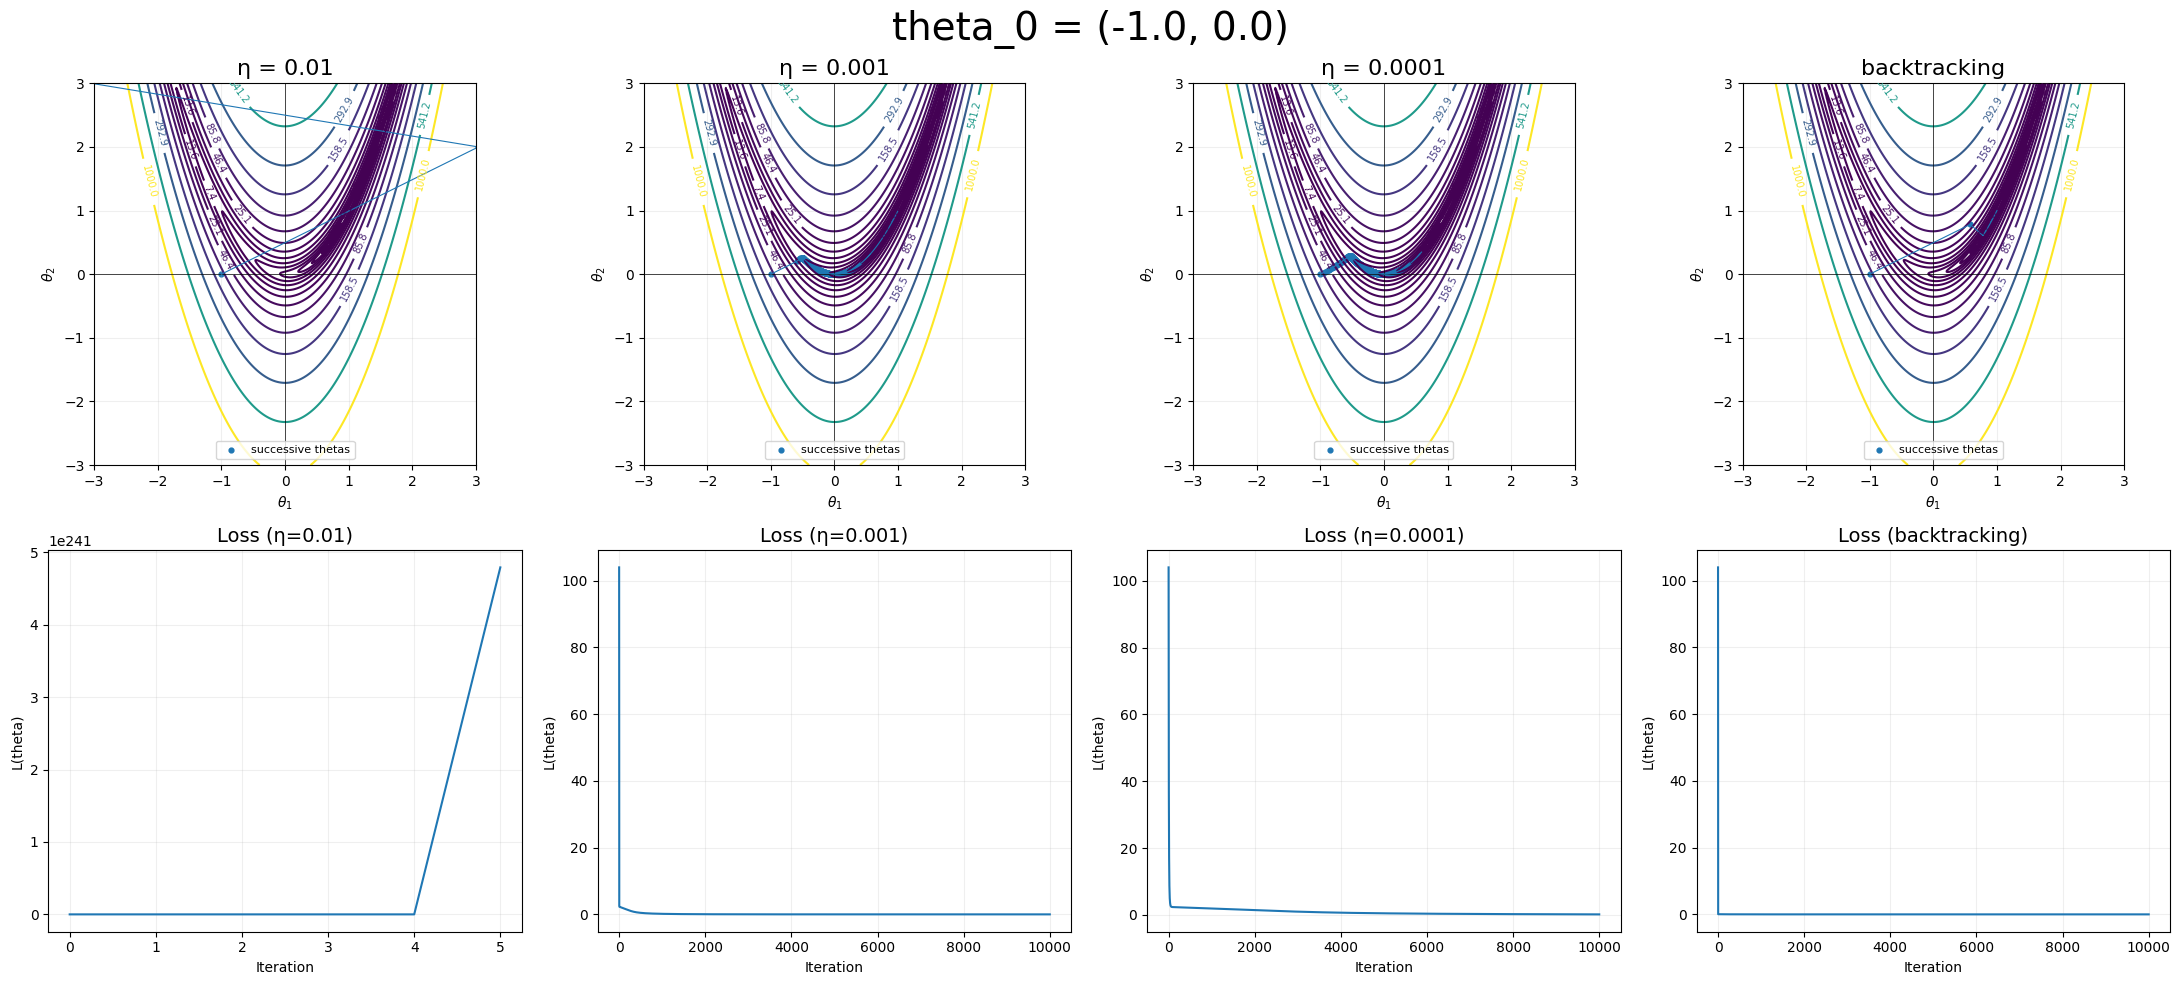

/var/folders/r0/xh7tlw6d25s7y_rpyn703zjw0000gn/T/ipykernel_2528/1726074894.py:7: RuntimeWarning: overflow encountered in scalar multiply
  g0 = -2 * (1 - theta[0]) - 400 * theta[0] * (theta[1] - theta[0]**2)
/var/folders/r0/xh7tlw6d25s7y_rpyn703zjw0000gn/T/ipykernel_2528/1726074894.py:48: RuntimeWarning: invalid value encountered in subtract
  theta_next = theta - eta * g


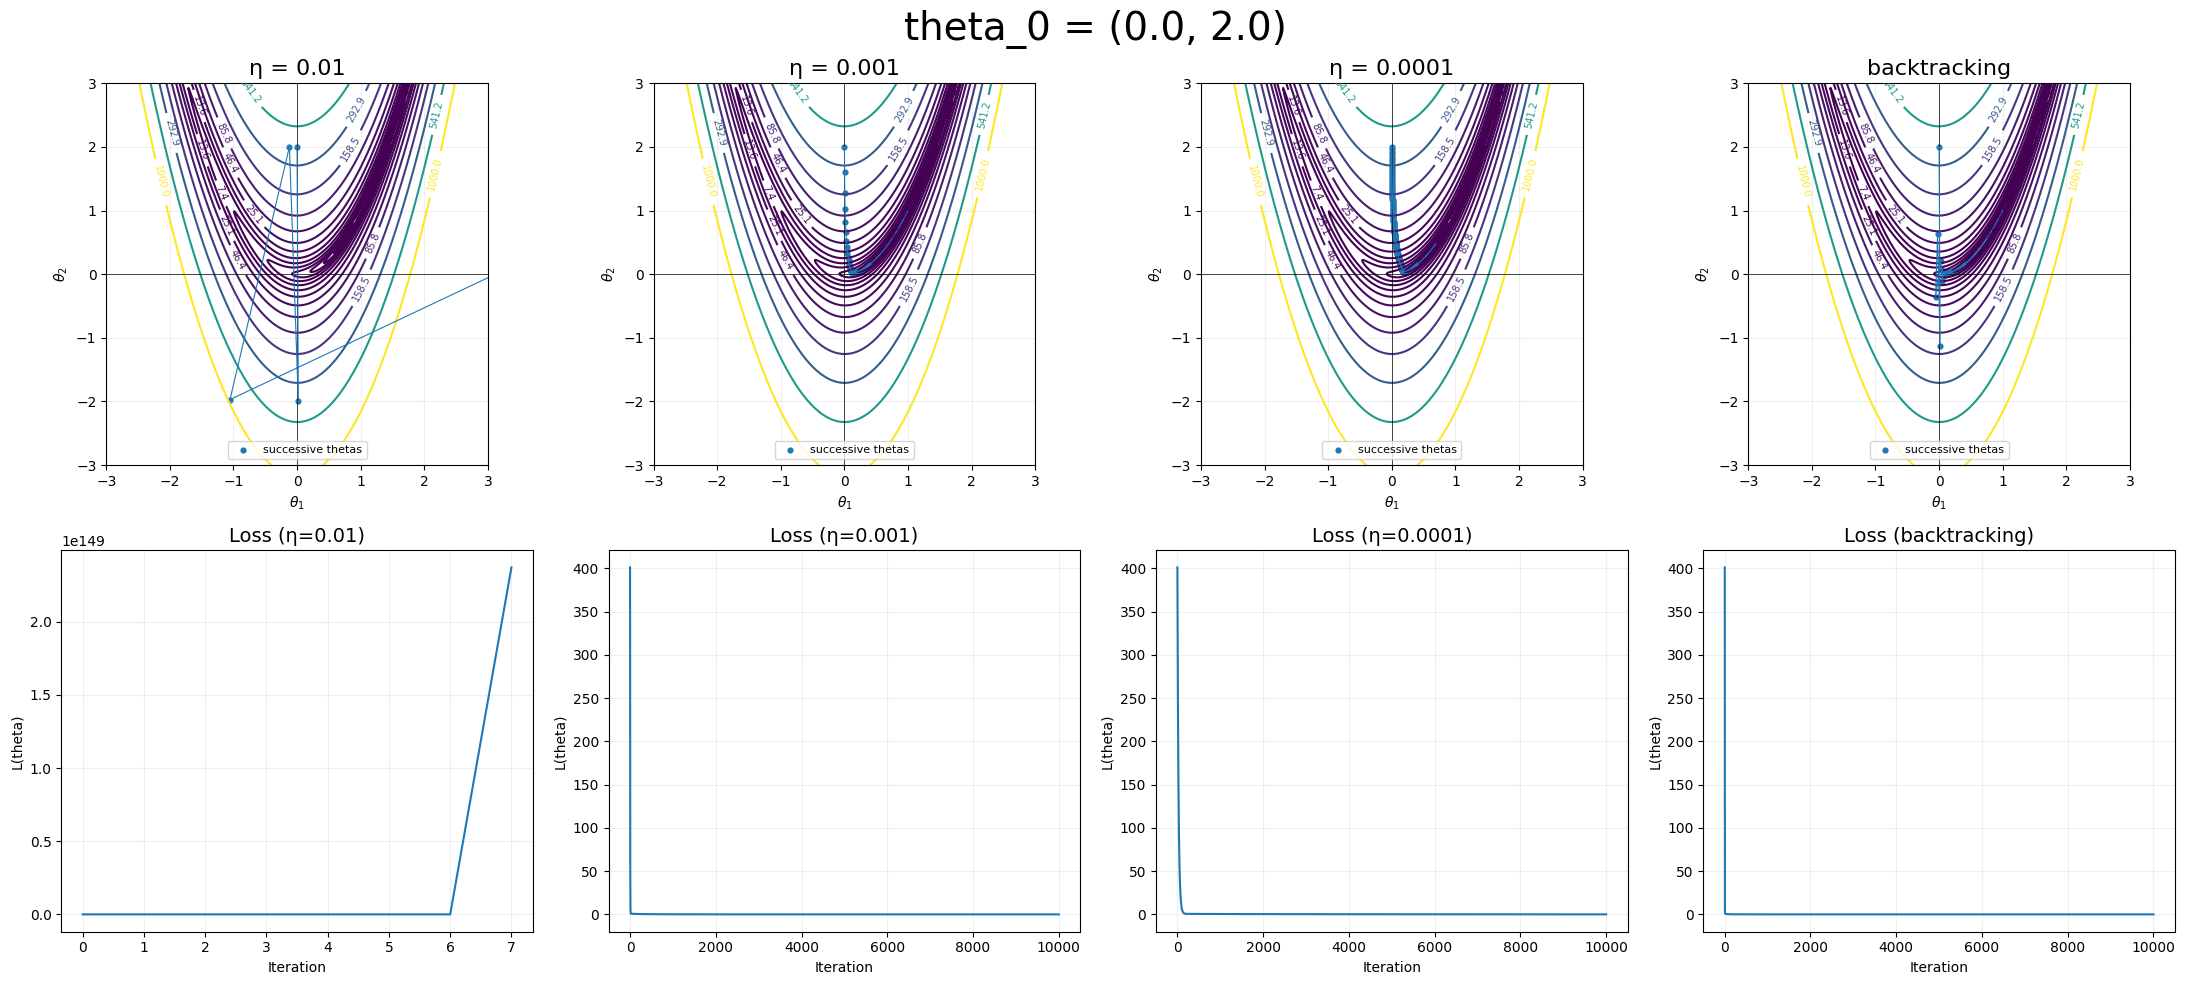

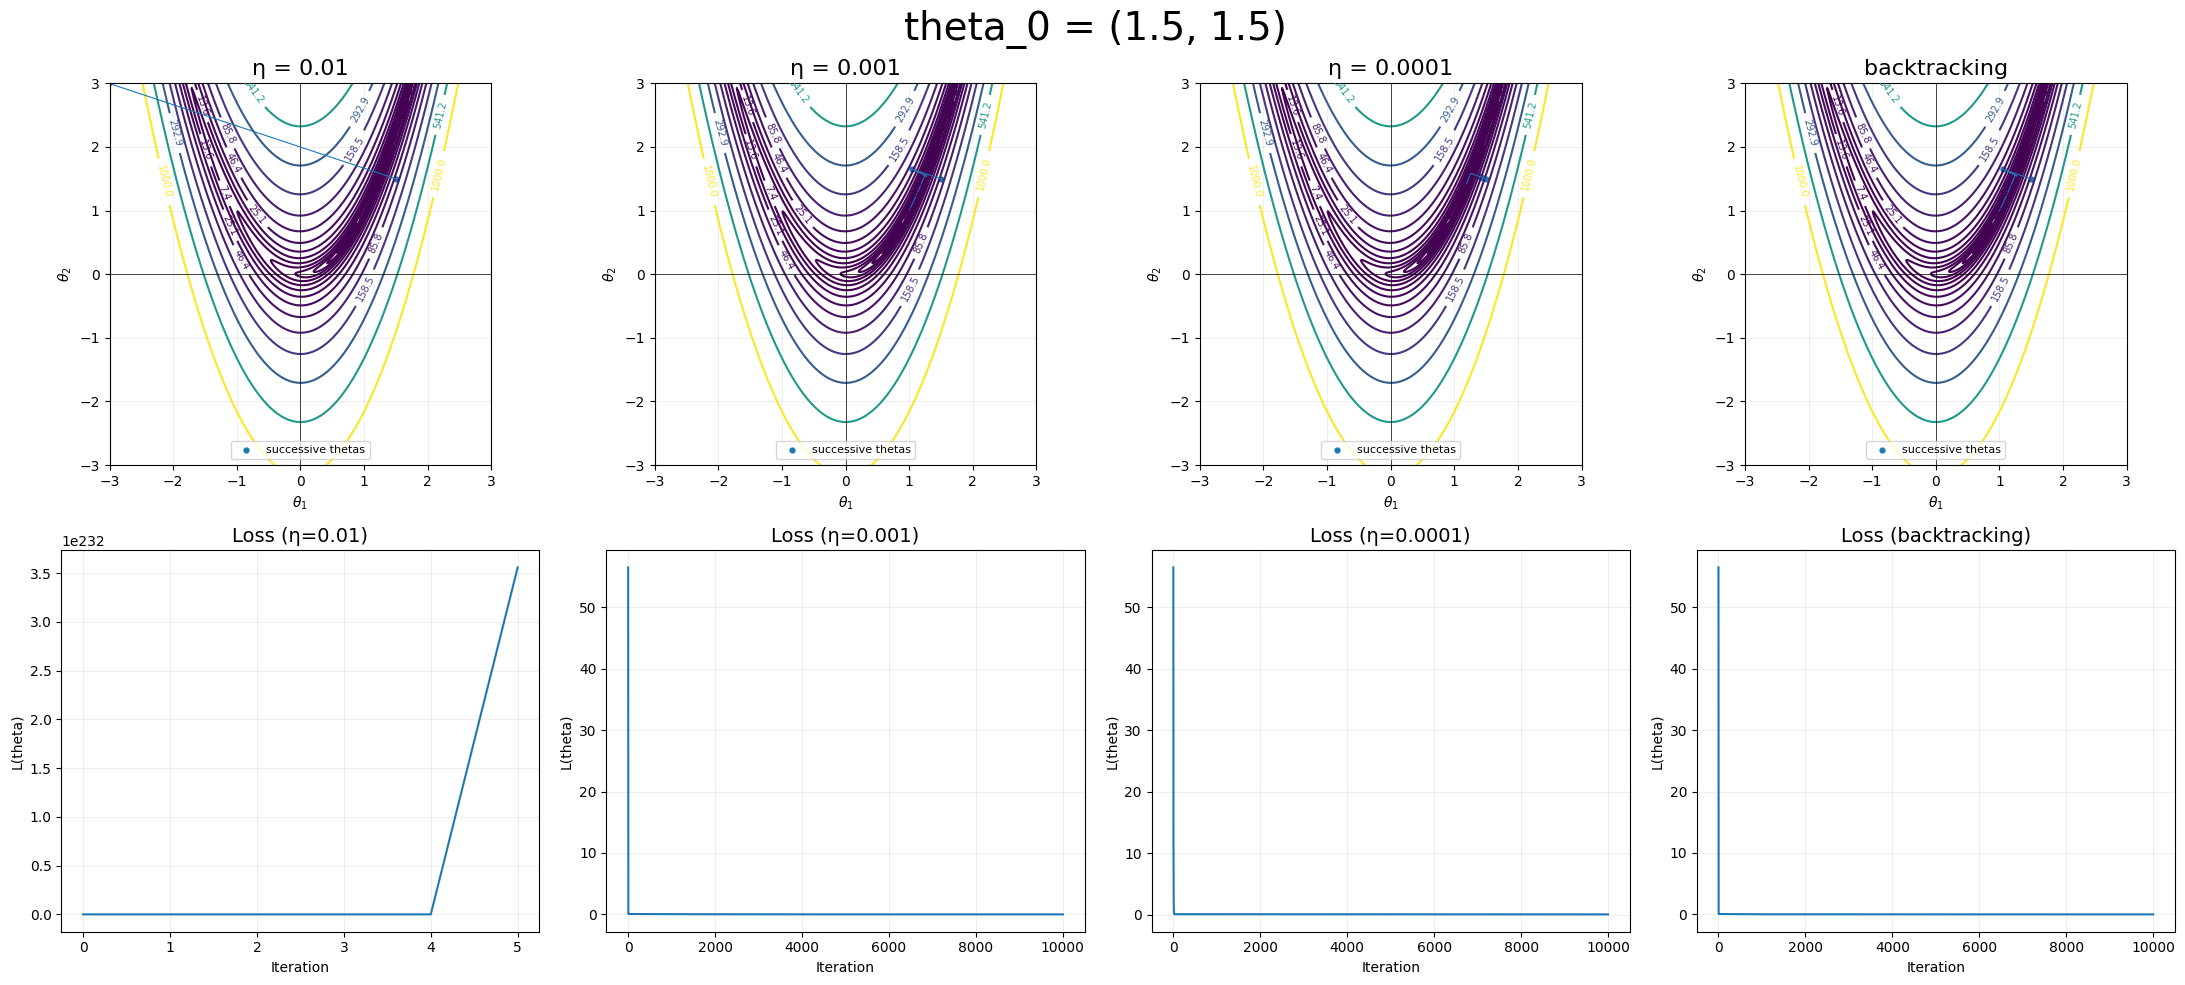

In [73]:
for theta0 in theta0_list:
    plot_one_theta0(
        theta0=theta0,
        etas_const=etas_const,
        eta_bt=1.0,
        maxit=10000,
        tolL=1e-6,
        toltheta=1e-10,
        xlim=(-3, 3),
        ylim=(-3, 3),
        ncontours=16
    )